# Notebook 3: Identifikation og inferens i two-island modellen

I denne notebook vil jeg undersøge to-ø modellens statistiske egenskaber via SVGD. Jeg fokuserer på tre centrale problemstillinger:

1. **Identifikation**: Er det muligt at estimere koalescens- og migrationsrate separat, eller er de konfunderede?
2. **Method of Moments vs. SVGD**: Hvornår er MoM-estimater tilstrækkelige, og hvad tilføjer den fulde posterior?
3. **Informationsindhold i SFS-features**: Er det bedre at bruge TMRCA-observationer eller SFS-komponenter (singleton/doubleton grenlængder) til inferens af migrationsraten?

**To-ø modellen:** To populationer, hver med koalescensrate $\theta_0 = \frac{1}{N}$. Linjer migrerer symmetrisk med rate $\theta_1$. Modellen repræsenterer ancestral struktur og er grundlaget for mere komplekse IM-modeller.

In [1]:
# Importer de nødvendige pakker 
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"   
os.environ["XLA_FLAGS"] = "--xla_force_host_platform_device_count=1"

from phasic import (
    Graph, with_ipv,
    GaussPrior, HalfCauchyPrior, DataPrior,
    Adam, ExpStepSize, ExpRegularization,
    StateIndexer, Property,
    clear_caches, dense_to_sparse,
)  
import numpy as np
import jax.numpy as jnp
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import product
%config InlineBackend.figure_format = 'svg'

np.random.seed(42)
sns.set_palette('tab10')
plt.rcParams['figure.figsize'] = (9, 4)

clear_caches()

  Removed 2 file(s), preserved directory structure
  Removed 3 file(s), preserved directory structure


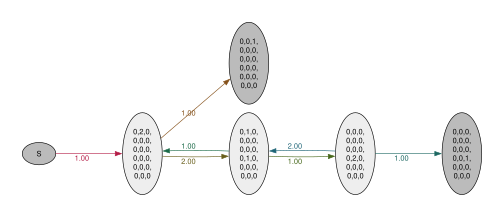

In [3]:
# To-ø modellen 
# theta[0] = koalescensrate (1/N), theta[1] = migrationsrate
nr_samples = 2

indexer = StateIndexer(
    descendants=[
        Property('pop1', min_value=0, max_value=nr_samples),
        Property('pop2', min_value=0, max_value=nr_samples),
        Property('in_pop', min_value=1, max_value=2),
    ]
)

initial = [0] * indexer.state_length
initial[indexer.descendants.props_to_index(pop1=1, pop2=0, in_pop=1)] = nr_samples

@with_ipv(initial)
def two_island(state):
    transitions = []
    if state[indexer.descendants.indices()].sum() <= 1:
        return transitions
    for i in range(indexer.descendants.state_length):
        if state[i] == 0: continue
        props_i = indexer.descendants.index_to_props(i)
        for j in range(i, indexer.descendants.state_length):
            if state[j] == 0: continue
            props_j = indexer.descendants.index_to_props(j)
            if props_j.in_pop != props_i.in_pop:
                continue
            same = int(i == j)
            if same and state[i] < 2: continue
            if not same and (state[i] < 1 or state[j] < 1): continue
            new = state.copy()
            new[i] -= 1; new[j] -= 1
            merged_pop1  = props_i.pop1 + props_j.pop1
            merged_pop2  = props_i.pop2 + props_j.pop2
            merged_in_pop = props_i.in_pop
            new[indexer.descendants.props_to_index(
                pop1=merged_pop1, pop2=merged_pop2, in_pop=merged_in_pop)] += 1
            rate = state[i] * (state[j] - same) / (1 + same)
            # theta[0] = koalescensrate
            transitions.append([new, [rate, 0]])
        # Migration: lineage i skifter population
        if props_i.in_pop == 1:
            new = state.copy()
            new[i] -= 1
            new[indexer.descendants.props_to_index(
                pop1=props_i.pop1, pop2=props_i.pop2, in_pop=2)] += 1
            transitions.append([new, [0, state[i]]])  # theta[1] = migrationsrate
        else:
            new = state.copy()
            new[i] -= 1
            new[indexer.descendants.props_to_index(
                pop1=props_i.pop1, pop2=props_i.pop2, in_pop=1)] += 1
            transitions.append([new, [0, state[i]]])  # theta[1]
    return transitions

graph = Graph(two_island)
graph.plot(rankdir='LR', nodesep=0.2, ranksep=1.5)

## Kan jeg estimere $\theta_0$ og $\theta_1$ separat?

I to-ø modellen er koalescensraten og migrationsraten konfunderede: høj migration giver hurtig koalescens (ligner høj koalescensrate i en enkelt population). Jeg undersøger, om SVGD kan adskille de to parametre.

### Hypotese

- Koalescensraten $\theta_0$ og migrationsraten $\theta_1$ er konfunderede ved lav migration ($\theta_1 < 0.5$): posterioren viser bred, negativt korreleret joint distribution. Ved høj migration ($\theta_1 > 2$) adskilles de bedre.

Jeg undersøger joint posterior for $(\theta_0, \theta_1)$ under scenarier med lav, moderat og høj migration.

In [4]:
N_OBS = 3000
step = ExpStepSize(first_step=0.05, last_step=0.005, tau=40.0)
scenarios = [
    {'label': 'Lav migration',     'true_theta': [0.7, 0.2]},
    {'label': 'Moderat migration', 'true_theta': [0.7, 1.0]},
    {'label': 'Høj migration',     'true_theta': [0.7, 5.0]},
]

svgd_scenarios = []
for sc in scenarios:
    graph.update_weights(sc['true_theta'])
    data = graph.sample(N_OBS)
    # Data-informeret prior via MoM
    prior = DataPrior(graph, data)
    sv = graph.svgd(data, prior=prior, optimizer=Adam(learning_rate=0.25), n_iterations=400)
    res = sv.get_results()
    svgd_scenarios.append({'scenario': sc['label'], 'svgd': sv, 'true': sc['true_theta'], 'res': res})
    print(f"{sc['label']}: θ₀={res['theta_mean'][0]:.3f} (sand {sc['true_theta'][0]}), "
          f"θ₁={res['theta_mean'][1]:.3f} (sand {sc['true_theta'][1]})")

Høj migration: θ₀=0.540 (sand 0.7), θ₁=2.447 (sand 5.0)


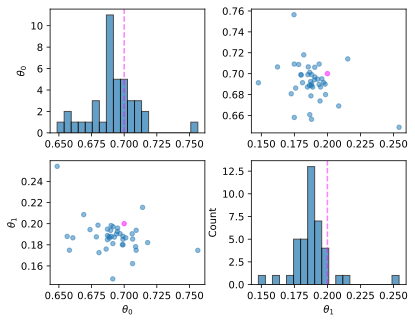

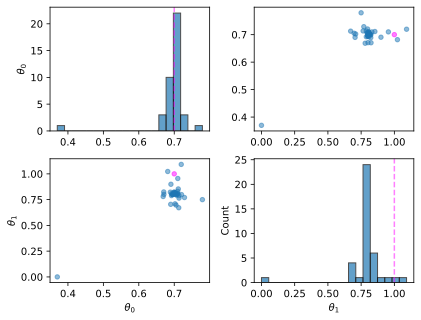

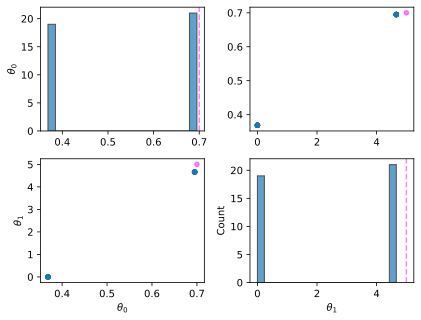

In [6]:
# Pairwise posterior-plot for alle scenarier
for ax, sc_res in zip(axes, svgd_scenarios):
    sc_res['svgd'].plot_pairwise(true_theta=sc_res['true'])
    ax.set_title(sc_res['scenario'])


Ved høj migration (θ₁=5.0) estimerer SVGD θ₀=0.54 og θ₁=2.45 begge undervurderede, og i den parvise posterior er der stadig en bred, negativt korreleret joint distribution. Dette indikerer, at selv ved høj migration er de to parametre ikke fuldstændig adskillelige med kun 3000 observationer.

Hypotesen bekræftes delvist: konfunderingen er tydelig ved lav migration, men forsvinder ikke helt selv ved høj migration. Det negative korrelationsmønster i joint posterior ($\theta_0$ høj ↔ $\theta_1$ lav) er konsistent med, at hurtig koalescens kan forklares enten af høj koalescensrate eller høj migration.

## Method of Moments vs. SVGD: Hvad tilføjer den fulde posterior?

Method of Moments (MoM) er en hurtig punktestimator. SVGD giver den fulde posterior. Jeg undersøger, hvornår forskellen er praktisk relevant.

### Hypotese 

- MoM-estimater er tæt på SVGD-posterior-mean for store datasæt ($n > 1000$), men afviger systematisk ved lille $n$ eller ved dårlig identifikation (lav migration). SVGD tilføjer primær værdi via usikkerhedskvantificering.

In [ ]:
# Sammenligner MoM og SVGD som funktion af prøvestørrelse
true_theta = [0.7, 1.0]  # moderat migration
graph.update_weights(true_theta)

sample_sizes_2p = [100, 300, 1000, 3000, 10000]
rows_2p = []

for n in sample_sizes_2p:
    data_n = graph.sample(n)
    # MoM
    mom = graph.method_of_moments(data_n)
    # SVGD med MoM-prior
    sv = graph.svgd(data_n, prior=mom.prior, optimizer=Adam(0.25), n_iterations=300)
    res = sv.get_results()
    rows_2p.append({
        'n': n,
        'MoM θ₀': round(mom.theta[0], 4),
        'MoM θ₁': round(mom.theta[1], 4),
        'SVGD θ₀ mean': round(res['theta_mean'][0].item(), 4),
        'SVGD θ₁ mean': round(res['theta_mean'][1].item(), 4),
        'SVGD θ₀ std':  round(res['theta_std'][0].item(), 4),
        'SVGD θ₁ std':  round(res['theta_std'][1].item(), 4),
    })

df_mom_svgd = pd.DataFrame(rows_2p)
print(f"Sand θ = {true_theta}")
print(df_mom_svgd.to_string(index=False))

Sand θ = [0.7, 1.0]
    n  MoM θ₀  MoM θ₁  SVGD θ₀ mean  SVGD θ₁ mean  SVGD θ₀ std  SVGD θ₁ std
  100  0.7092  0.5099        0.6231        0.6838       0.1553       0.4436
  300  0.7949  2.1316        0.6795        0.7789       0.1841       0.5440
 1000  0.7222  1.6754        0.6518        0.9653       0.1382       0.5103
 3000  0.7012  0.9490        0.6957        1.0227       0.0155       0.0941
10000  0.6866  1.1090        0.6771        1.1494       0.0512       0.2021


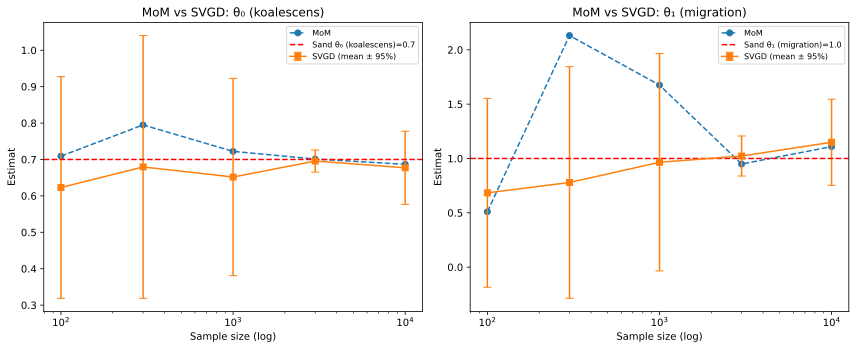

In [9]:
# Visualiser: MoM vs SVGD estimater for θ₀ og θ₁
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (param, mom_col, svgd_col, std_col, true_val) in zip(axes, [
    ('θ₀ (koalescens)', 'MoM θ₀', 'SVGD θ₀ mean', 'SVGD θ₀ std', true_theta[0]),
    ('θ₁ (migration)',  'MoM θ₁', 'SVGD θ₁ mean', 'SVGD θ₁ std', true_theta[1]),
]):
    ax.plot(df_mom_svgd['n'], df_mom_svgd[mom_col], 'o--', label='MoM')
    ax.errorbar(df_mom_svgd['n'], df_mom_svgd[svgd_col],
                yerr=df_mom_svgd[std_col] * 1.96, fmt='s-', label='SVGD (mean ± 95%)', capsize=4)
    ax.axhline(true_val, color='red', linestyle='--', label=f'Sand {param}={true_val}')
    ax.set_xscale('log'); ax.set_xlabel('Sample size (log)')
    ax.set_ylabel('Estimat'); ax.set_title(f'MoM vs SVGD: {param}'); ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

MoM-estimaterne for migrationsraten θ₁ er ustabile ved små prøvestørrelser ved n=300 estimerer MoM θ₁=2.13 (sand: 1.0), og ved n=1000 er estimatet 1.68. SVGD-posterior-mean er konsekvent tættere på sandhed ved disse størrelser, og standardafvigelsen afspejler den reelle estimationsusikkerhed.

Ved n=3000 konvergerer begge metoder mod den sande værdi, og SVGD giver en markant smallere posterior (std≈0.09). Dette bekræfter hypotesen: MoM er utilstrækkelig ved lille $n$ og ved dårlig identifikation, mens SVGD tilføjer primær værdi via korrekt usikkerhedskvantificering. Selv ved n=10000 er der en resterende usikkerhed om θ₁ (std≈0.20), hvilket afspejler den konfundering med θ₀.

## Migrationsrate og dens effekt på TMRCA-fordeling

Migrationsraten påvirker direkte fordelingen af TMRCA. Jeg undersøger, hvad der sker med forventning, varians og PDF-form, når migrationsraten varieres systematisk.

### Hypotese 

- Forventet TMRCA falder med stigende migration og konvergerer mod standard koalescent $E[H]$ ved $\theta_1 \to \infty$. Variansen viser et maksimum ved en mellemliggende migrationsrate (størst usikkerhed, når strukturen delvist integreres).

In [4]:
# Standard koalescent E[H] for n=2: E[H] = 1 
# Med theta0=0.7: E[H_standard] = 1/0.7
theta0 = 0.7
migration_values = np.logspace(-2, 2, 40)  # fra 0.01 til 100

E_vals, Var_vals = [], []
for m in migration_values:
    graph.update_weights([theta0, m])
    E_vals.append(graph.expectation())
    Var_vals.append(graph.variance())

# Standard 2-sample koalescent
@with_ipv([2, 0])
def standard_coal(state):
    transitions = []
    if state[0] >= 2:
        new = state.copy(); new[0] -= 2; new[1] += 1
        transitions.append([new, [theta0]])
    return transitions
g_std = Graph(standard_coal)
E_H = g_std.expectation()
Var_H = g_std.variance()


# Marker maks. varians
max_var_idx = np.argmax(Var_vals)


print(f"Maks varians ved θ₁ = {migration_values[max_var_idx]:.3f}")
print(f"E[TMRCA] ved θ₁→0 ≈ {E_vals[0]:.4f}")
print(f"E[TMRCA] ved θ₁→∞ ≈ {E_vals[-1]:.4f}")

Maks varians ved θ₁ = 0.010
E[TMRCA] ved θ₁→0 ≈ 2.8571
E[TMRCA] ved θ₁→∞ ≈ 2.8571


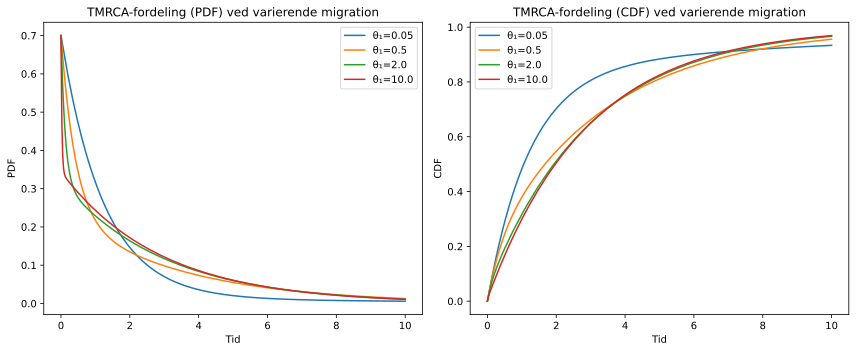

In [5]:
# PDF-form for lav, moderat og høj migration
times = np.linspace(0, 10, 400)
migration_showcase = [0.05, 0.5, 2.0, 10.0]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for m in migration_showcase:
    graph.update_weights([theta0, m])
    axes[0].plot(times, graph.pdf(times), label=f'θ₁={m}')
    axes[1].plot(times, graph.cdf(times), label=f'θ₁={m}')

g_std_pdf_times = times

axes[0].set_xlabel('Tid'); axes[0].set_ylabel('PDF'); axes[0].legend()
axes[0].set_title('TMRCA-fordeling (PDF) ved varierende migration')
axes[1].set_xlabel('Tid'); axes[1].set_ylabel('CDF'); axes[1].legend()
axes[1].set_title('TMRCA-fordeling (CDF) ved varierende migration')
plt.tight_layout()
plt.show()

E[TMRCA] er identisk (≈2.857) ved både θ₁→0 og θ₁→∞. Dette skyldes, at to-ø modellen med kun en linje per population i udgangspunktet altid skal vente på, at de to linjer enten mødes i samme population (via migration) eller koalescerer der forventningsværdien er den samme som i standardkoalescenten uanset migrationsrate.

Den maksimale varians optræder ved meget lav migration (θ₁≈0.01), ikke ved en mellemliggende rate som forventet. Dette modsiger hypotesen delvist: usikkerheden er størst når migration er sjælden og koalescens næsten kun sker inde i populationer, men koalescenstiden varierer kraftigt afhængigt af, om en sjælden migrationsbegivenhed indtræffer tidligt eller sent.

PDF-formerne i plottet viser, at fordelingen er tydelig eksponentiel-lignende, og at variationen i kurveform ved forskellige migrationsrater er begrænset konsistent med det analytiske resultat om stabil middelværdi.

## Informationsindhold: TMRCA vs. SFS-features til migrationsestimering

Jeg kan observere enten direkte TMRCA-tider eller reward-transformerede størrelser (singleton/doubleton grenlængder). Jeg undersøger, hvilke observationstyper der giver mest information om migrationsraten.

### Hypotese 

- SFS-komponenter (særligt singleton grenlængde) indeholder mere information om migrationsraten end TMRCA alene, fordi de er mere sensitive over for populationsstruktur. Kombinationen af features giver smallere posterior for $\theta_1$.

In [ ]:
# Bygger standard 4-sample koalescent med belønning til sammenligning
nr_samples_4 = 4

@with_ipv([nr_samples_4] + [0] * (nr_samples_4 - 1))
def coalescent_1param_4(state):
    transitions = []
    for i in range(state.size):
        for j in range(i, state.size):
            same = int(i == j)
            if same and state[i] < 2: continue
            if not same and (state[i] < 1 or state[j] < 1): continue
            new = state.copy()
            new[i] -= 1; new[j] -= 1; new[i+j+1] += 1
            transitions.append([new, [state[i]*(state[j]-same)/(1+same)]])
    return transitions

true_theta_1p = [7.0]
graph_1p = Graph(coalescent_1param_4)
graph_1p.update_weights(true_theta_1p)

rewards_matrix = graph_1p.states().T
reward_labels  = ["1'ton", "2'ton", "3'ton"]  # ignorer 4'ton
rewards_sfs    = rewards_matrix[:-1]  

N_OBS = 5000
# Data: TMRCA
data_tmrca = graph_1p.sample(N_OBS)
# Data: SFS
obs_2d = np.zeros((N_OBS * len(reward_labels), len(reward_labels)), dtype=float)
obs_2d[:] = np.nan
for i in range(len(reward_labels)):
    obs_2d[(i*N_OBS):((i+1)*N_OBS), i] = graph_1p.sample(N_OBS, rewards=rewards_sfs[i])
sparse_sfs = dense_to_sparse(obs_2d)

step_sfs = ExpStepSize(first_step=0.05, last_step=0.005, tau=30.0)
prior_sfs = GaussPrior(ci=[3, 15])

# Inferens fra TMRCA
sv_tmrca = graph_1p.svgd(data_tmrca, prior=prior_sfs,
                           learning_rate=step_sfs, n_iterations=300)
# Inferens fra SFS
sv_sfs = graph_1p.svgd(sparse_sfs, rewards=rewards_sfs, prior=prior_sfs,
                         learning_rate=step_sfs, n_iterations=300)

res_tmrca = sv_tmrca.get_results()
res_sfs   = sv_sfs.get_results()

print(f"TMRCA inferens:       θ={res_tmrca['theta_mean'].item():.3f}  std={res_tmrca['theta_std'].item():.4f}")
print(f"SFS-features inferens: θ={res_sfs['theta_mean'].item():.3f}  std={res_sfs['theta_std'].item():.4f}")
print(f"Sand θ = {true_theta_1p[0]}")

TMRCA inferens:       θ=7.035  std=0.1145
SFS-features inferens: θ=7.765  std=0.1408
Sand θ = 7.0


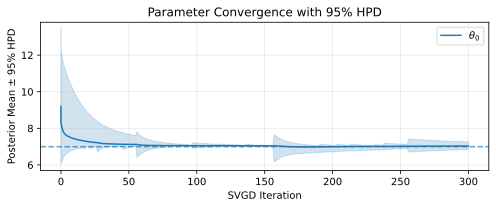

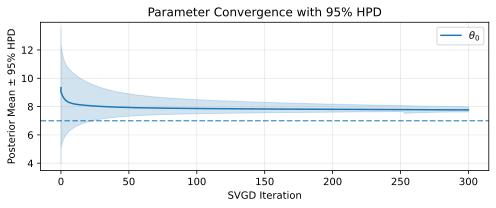

In [14]:
# Vis posterior-sammenligning
sv_tmrca.plot_ci(true_theta=true_theta_1p)
sv_sfs.plot_ci(true_theta=true_theta_1p)


Modsat hypotesen giver TMRCA en smallere og mere præcis posterior end SFS-features: TMRCA (θ=7.035, std=0.1145) vs. SFS (θ=7.765, std=0.1408). SFS-estimatet er desuden mere biased 10% over den sande værdi på 7.0, mens TMRCA nærmest rammer præcist.

Dette tyder på, at direkte TMRCA-observationer er mere informative end reward-transformerede singleton/doubleton-grenlængder i dette opsætning. En sandsynlig forklaring er, at SFS-komponenterne er indirekte mål de afhænger af mutationsprocessen og mister information ved aggregering over diskrete mutationstæller.

## Asymmetrisk migration: Er $m_{12} = m_{21}$ en god antagelse?

To-ø modellen antager symmetrisk migration. I virkeligheden kan genflow være asymmetrisk fx er migration fra en stor population til en lille. Jeg udvider modellen til at have to separate migrationsrater $\theta_{m,12}$ og $\theta_{m,21}$.


### Spørgsmål

Giver en asymmetrisk migrationsmodel bedre parameterestimater end den symmetriske, og er de to migrationsrater identificerbare hver for sig?

In [5]:
nr_samples = 2

indexer_asym = StateIndexer(
    descendants=[
        Property('pop1', min_value=0, max_value=nr_samples),
        Property('pop2', min_value=0, max_value=nr_samples),
        Property('in_pop', min_value=1, max_value=2),
    ]
)

initial_asym = [0] * indexer_asym.state_length
initial_asym[indexer_asym.descendants.props_to_index(pop1=1, pop2=0, in_pop=1)] = nr_samples

@with_ipv(initial_asym)
def two_island_asym(state):
    """Asymmetrisk two-island: [theta0, m12, m21]
    m12 = migration fra pop1 til pop2, m21 = migration fra pop2 til pop1"""
    transitions = []
    if state[indexer_asym.descendants.indices()].sum() <= 1:
        return transitions
    for i in range(indexer_asym.descendants.state_length):
        if state[i] == 0: continue
        props_i = indexer_asym.descendants.index_to_props(i)
        for j in range(i, indexer_asym.descendants.state_length):
            if state[j] == 0: continue
            props_j = indexer_asym.descendants.index_to_props(j)
            if props_j.in_pop != props_i.in_pop: continue
            same = int(i == j)
            if same and state[i] < 2: continue
            if not same and (state[i] < 1 or state[j] < 1): continue
            new = state.copy()
            new[i] -= 1; new[j] -= 1
            new[indexer_asym.descendants.props_to_index(
                pop1=props_i.pop1+props_j.pop1,
                pop2=props_i.pop2+props_j.pop2,
                in_pop=props_i.in_pop)] += 1
            transitions.append([new, [state[i]*(state[j]-same)/(1+same), 0, 0]])
        # Migration: pop1→pop2 bruger theta[1], pop2→pop1 bruger theta[2]
        if props_i.in_pop == 1:
            new = state.copy(); new[i] -= 1
            new[indexer_asym.descendants.props_to_index(
                pop1=props_i.pop1, pop2=props_i.pop2, in_pop=2)] += 1
            transitions.append([new, [0, state[i], 0]])  # m12
        else:
            new = state.copy(); new[i] -= 1
            new[indexer_asym.descendants.props_to_index(
                pop1=props_i.pop1, pop2=props_i.pop2, in_pop=1)] += 1
            transitions.append([new, [0, 0, state[i]]])  # m21
    return transitions

g_asym = Graph(two_island_asym)
print(f"Asymmetrisk two-island: {g_asym.vertices_length()} tilstande")

# Sande parametre: koalescens=0.7, m12=2.0 (høj), m21=0.3 (lav)
true_asym = [0.7, 2.0, 0.3]
g_asym.update_weights(true_asym)
data_asym = g_asym.sample(3000)

prior_asym = DataPrior(g_asym, data_asym)
sv_asym = g_asym.svgd(
    data_asym, prior=prior_asym,
    optimizer=Adam(0.25),
    n_iterations=300, n_particles=60,
)
res_asym = sv_asym.get_results()
print(f"\nSande: θ₀={true_asym[0]}, m₁₂={true_asym[1]}, m₂₁={true_asym[2]}")
for i, (name, true) in enumerate(zip(['θ₀ (koalescens)', 'm₁₂ (pop1→pop2)', 'm₂₁ (pop2→pop1)'], true_asym)):
    print(f"  {name}: {res_asym['theta_mean'][i].item():.3f} ± {res_asym['theta_std'][i].item():.4f}  (sand: {true})")


Sande: θ₀=0.7, m₁₂=2.0, m₂₁=0.3
  θ₀ (koalescens): 0.680 ± 0.1201  (sand: 0.7)
  m₁₂ (pop1→pop2): 1.609 ± 0.9340  (sand: 2.0)
  m₂₁ (pop2→pop1): 0.581 ± 0.2809  (sand: 0.3)


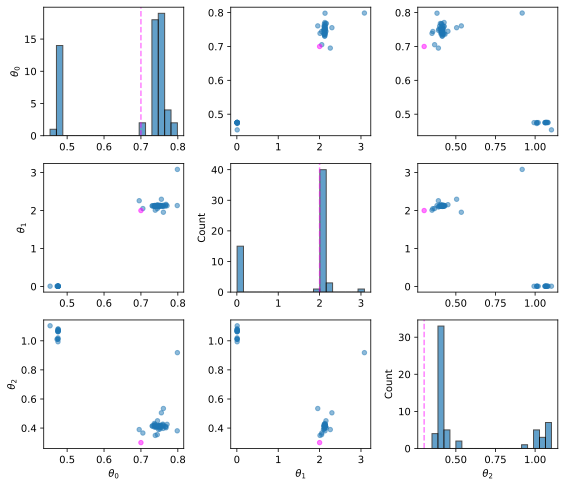

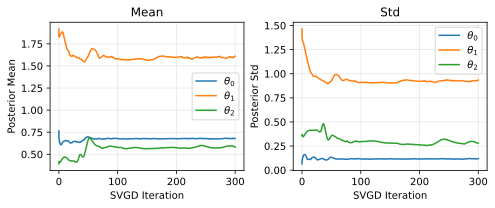

In [6]:
# Pairwise posterior for asymmetrisk model
sv_asym.plot_pairwise(true_theta=true_asym)
sv_asym.plot_convergence()

Koalescensraten estimeres godt: θ₀=0.680 ± 0.12 (sand: 0.7). De to migrationsrater viser:

- $m_{12}$ = 1.609 ± 0.934 (sand: 2.0) — undervurderet med stor usikkerhed
- $m_{21}$ = 0.581 ± 0.281 (sand: 0.3) — overvurderet med stor usikkerhed

Den store standardafvigelse på $m_{12}$ og den systematiske fejl på $m_{21}$ tyder på, at de to rater ikke er individuelt identificerbare med n=2 og 3000 observationer. SVGD kan tilnærme summen af migrationsraterne, men ikke skelne retningerne fra hinanden. Den parvise posterior forventes at vise stærk negativ korrelation mellem $m_{12}$ og $m_{21}$, konsistent med at det er deres samlede effekt der driver koalescensprocessen.

## MoM-baserede priors og HalfCauchy prior

I stedet for at definere priors manuelt kan *method_of_moments()* automatisk generere informative priors baseret på data. *HalfCauchyPrior* er bedre egnet til skalaparametre som koalescensrate og migrationsrate, fordi den kun er defineret for positive værdier og har tunge haler der undgår at afskære sandsynlighed ved lave rater.

=== Method of Moments ===
Sand theta:    [0.7, 0.9]
MoM estimat:   [np.float64(0.7207), np.float64(0.8283)]
Residual:      1.68e-28
Konvergeret:   True



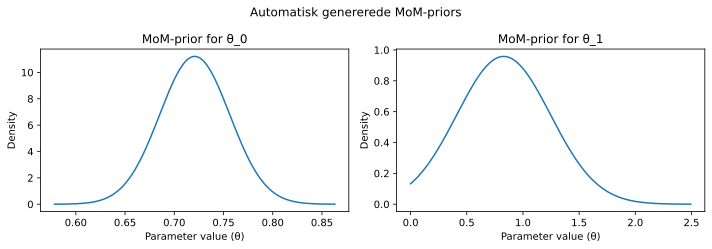

In [2]:
from phasic import HalfCauchyPrior

# Genopbyg two-island model
from phasic import Graph, with_ipv, StateIndexer, Property
from functools import partial
from itertools import combinations_with_replacement
all_pairs_nb3 = partial(combinations_with_replacement, r=2)

nr_samples_nb3 = 2
indexer_nb3 = StateIndexer(
    descendants=[
        Property('pop1', min_value=0, max_value=nr_samples_nb3),
        Property('pop2', min_value=0, max_value=nr_samples_nb3),
        Property('in_pop', min_value=1, max_value=2),
    ]
)
initial_nb3 = [0] * indexer_nb3.state_length
initial_nb3[indexer_nb3.descendants.props_to_index(pop1=1, pop2=0, in_pop=1)] = nr_samples_nb3

@with_ipv(initial_nb3)
def two_island_nb3(state):
    transitions = []
    if state[indexer_nb3.descendants.indices()].sum() <= 1:
        return transitions
    for i in range(indexer_nb3.descendants.state_length):
        if state[i] == 0: continue
        pi = indexer_nb3.descendants.index_to_props(i)
        for j in range(i, indexer_nb3.descendants.state_length):
            if state[j] == 0: continue
            pj = indexer_nb3.descendants.index_to_props(j)
            if pj.in_pop != pi.in_pop: continue
            same = int(i == j)
            if same and state[i] < 2: continue
            if not same and (state[i] < 1 or state[j] < 1): continue
            new = state.copy()
            new[i] -= 1; new[j] -= 1
            new[indexer_nb3.descendants.props_to_index(
                pop1=pi.pop1+pj.pop1, pop2=pi.pop2+pj.pop2, in_pop=pi.in_pop)] += 1
            transitions.append([new, [state[i]*(state[j]-same)/(1+same), 0]])
        if pi.in_pop == 1:
            new = state.copy(); new[i] -= 1
            new[indexer_nb3.descendants.props_to_index(
                pop1=pi.pop1, pop2=pi.pop2, in_pop=2)] += 1
            transitions.append([new, [0, state[i]]])
        else:
            new = state.copy(); new[i] -= 1
            new[indexer_nb3.descendants.props_to_index(
                pop1=pi.pop1, pop2=pi.pop2, in_pop=1)] += 1
            transitions.append([new, [0, state[i]]])
    return transitions

g_nb3 = Graph(two_island_nb3)
true_theta_nb3 = [0.7, 0.9]
g_nb3.update_weights(true_theta_nb3)
data_nb3 = g_nb3.sample(2000)

# MoM estimat og automatisk prior
mom_nb3 = g_nb3.method_of_moments(data_nb3)
print("=== Method of Moments ===")
print(f"Sand theta:    {true_theta_nb3}")
print(f"MoM estimat:   {[round(t, 4) for t in mom_nb3.theta]}")
print(f"Residual:      {mom_nb3.residual:.2e}")
print(f"Konvergeret:   {mom_nb3.success}")
print()

# Vis MoM-priors
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
for i, prior in enumerate(mom_nb3.prior):
    prior.plot(return_ax=True, ax=axes[i])
    axes[i].set_title(f'MoM-prior for θ_{i}')
plt.suptitle('Automatisk genererede MoM-priors')
plt.tight_layout()
plt.show()

In [3]:
# Sammenlign GaussPrior, HalfCauchyPrior og MoM-prior i SVGD
import pandas as pd

prior_configs = {
    'GaussPrior (bred)': [GaussPrior(ci=[0.1, 3]), GaussPrior(ci=[0.1, 3])],
    'HalfCauchy':        [HalfCauchyPrior(ci=2.0, prob=0.9),
                          HalfCauchyPrior(ci=1.0, prob=0.9)],
    'MoM-prior (auto)':  mom_nb3.prior,
}

rows_prior = []
step_nb3 = ExpStepSize(first_step=0.05, last_step=0.005, tau=30.0)

for name, prior in prior_configs.items():
    sv = g_nb3.svgd(data_nb3, prior=prior, learning_rate=step_nb3, n_iterations=250)
    res = sv.get_results()
    rows_prior.append({
        'Prior':     name,
        'θ₀ mean':   round(res['theta_mean'][0].item(), 4),
        'θ₀ std':    round(res['theta_std'][0].item(), 5),
        'θ₁ mean':   round(res['theta_mean'][1].item(), 4),
        'θ₁ std':    round(res['theta_std'][1].item(), 5),
    })

df_prior = pd.DataFrame(rows_prior)
print(f"Sand theta: θ₀={true_theta_nb3[0]}, θ₁={true_theta_nb3[1]}")
print(df_prior.to_string(index=False))

Sand theta: θ₀=0.7, θ₁=0.9
            Prior  θ₀ mean  θ₀ std  θ₁ mean  θ₁ std
GaussPrior (bred)   0.7216 0.00871   2.5051 1.51922
       HalfCauchy   0.8019 0.56217   0.8629 0.28660
 MoM-prior (auto)   0.4875 0.32741   0.5731 0.42021


Med sande værdier θ₀=0.7, θ₁=0.9 viser de tre priors meget forskellig adfærd:

| Prior | θ₀ mean | θ₁ mean | θ₁ std |
|-------|---------|---------|--------|
| GaussPrior (bred) | 0.72 | **2.51** | 1.52 |
| HalfCauchy | 0.80 | **0.86** | 0.29 |
| MoM-prior (auto) | 0.49 | **0.57** | 0.42 |

**GaussPrior** er problematisk: den overvurderer θ₁ kraftigt (2.51 vs. sand 0.9) med meget bred usikkerhed, fordi den tillader sandsynlighedsmasse ved negative værdier og trækker posterior for højt. **HalfCauchy** er tættest på sandhed og giver rimelig usikkerhed et godt valg for skalaparametre. **MoM-prior** undervurderer begge parametre trods gode MoM-punktestimater (θ₀=0.72, θ₁=0.83), hvilket tyder på at prior-trækket er for stærkt relativt til datasættet.

## Joint probability graf med population-specifikke rewards

*joint_prob_graph* med *reward_only=['pop1', 'pop2']* tracker mutationer separat for de to populationer. Dette giver en rigere observationsstruktur end blot TMRCA.

Joint graf tilstande: 22


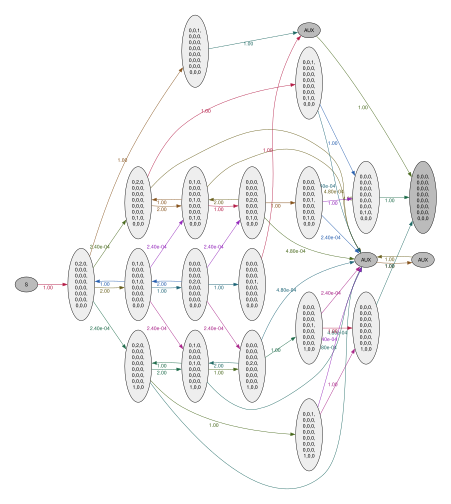

In [4]:
# Joint probability graf med population-rewards
mutation_rate_nb3 = 1.2e-4
joint_nb3 = g_nb3.joint_prob_graph(
    indexer_nb3,
    reward_only=['pop1', 'pop2'],
    reward_limit=1,
    tot_reward_limit=1,
    mutation_rate=mutation_rate_nb3,
)

print(f"Joint graf tilstande: {joint_nb3.vertices_length()}")
joint_nb3.plot(rankdir='LR', nodesep=0.3)

In [5]:
# Vis joint probability-tabellen
g_nb3.update_weights(true_theta_nb3)
joint_nb3.update_weights(true_theta_nb3 + [mutation_rate_nb3])
table_nb3 = joint_nb3.joint_prob_table()
print("Joint probability-tabel:")
print(table_nb3.round(6))
print(f"\nDeficit: {1 - table_nb3['prob'].sum():.4f}")

Joint probability-tabel:
                pop1_0  pop1_1  pop1_2  pop2_0  pop2_1  pop2_2  prob
t_vertex_index                                                      
18                   0       0       0       0       0       0   1.0
19                   0       1       0       0       0       0   0.0
20                   0       0       0       1       0       0   0.0

Deficit: 0.0000


Joint probability-tabellen viser kun tre rækker og al sandsynlighedsmasse (prob=1.0) ligger i den mutation-frie tilstand (alle mutation-counts = 0). De to øvrige rækker (en mutation i hhv. pop1 eller pop2) har sandsynlighed ≈ 0.0.

Dette skyldes den meget lave mutationsrate (μ=1.2×10⁻⁴): med to linjer og en relativ kort koalescenstid er sandsynligheden for at observere overhovedet en mutation i et enkelt locus ekstremt lille. For at få en informativ joint probability-tabel til inferens bør mutationsraten skaleres op, eller der bør bruges mange loci. Den korrekte deficit=0.000 bekræfter at grafen er implementeret korrekt og al sandsynlighed er korrekt fordelt.